In [ ]:
# In colab run this cell first to setup the file structure!
%cd /content
!rm -rf MOL518-Intro-to-Data-Analysis

!git clone https://github.com/shaevitz/MOL518-Intro-to-Data-Analysis.git
%cd MOL518-Intro-to-Data-Analysis/Lecture_32

# BPY518 Lecture 32: Image Preprocessing and Noise Reduction


## Lecture Outline
- Bit depth, dynamic range, and contrast
- Types of noise
- Noise filtering techniques
- Background subtraction



We will consider **single-channel grayscale images** in this lecture. The main goal is to understand how raw microscopy images get distorted by digitization, noise, and background, and what simple preprocessing steps are useful before downstream analysis.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Make notebook figures a bit sharper in Colab/Jupyter output.
plt.rcParams['figure.dpi'] = 120
# Display images in grayscale by default unless a cmap is set explicitly.
plt.rcParams['image.cmap'] = 'gray'


## Image Bit Depth

Light intensities are digitized into integers. If an image uses `N` bits, it can represent `2**N` distinct gray levels.

- 8-bit: 0 to 255
- 12-bit: 0 to 4095
- 16-bit: 0 to 65,535

![Bit depth comparison](media/bit_depth_comparison_2x2.png)


Here we use a real test image to demonstrate how contrast affects visibility. The low-contrast version simulates conditions like poor lighting or detector sensitivity where the signal is compressed into a narrow range of pixel values.

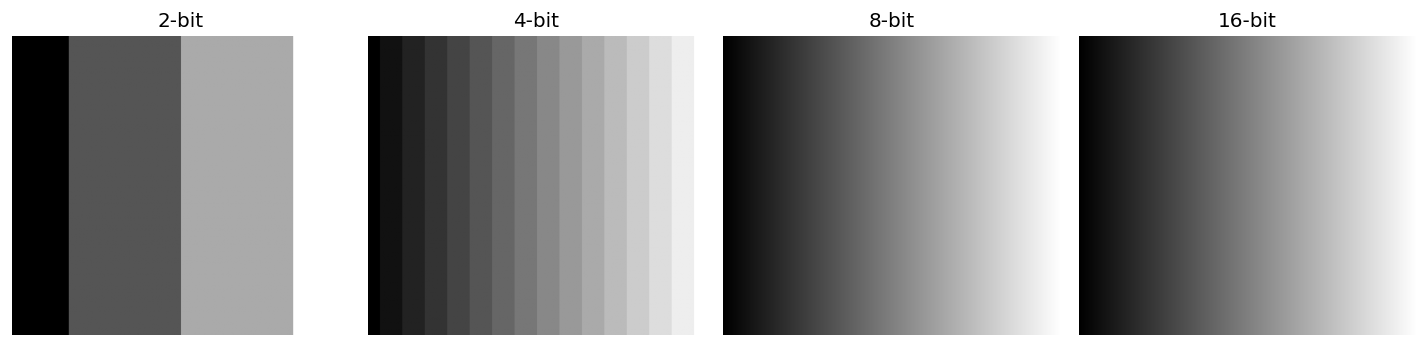

In [2]:
gradient = np.tile(np.linspace(0, 1, 256), (80, 1))

def quantize_to_n_bits(image, n_bits):
    levels = 2**n_bits - 1
    return np.round(image * levels) / levels

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, n_bits in zip(axes, [2, 4, 8, 16]):
    q = quantize_to_n_bits(gradient, n_bits)
    ax.imshow(q, vmin=0, vmax=1, aspect='auto')
    ax.set_title(f'{n_bits}-bit')
    ax.axis('off')

plt.tight_layout()
plt.show()

Here is another example:

![Bit depth levels 8-to-1](media/Cell_bitdepth.png)


## Dynamic Range and Contrast

Dynamic range in images refers to the **ratio between the brightest and darkest pixel intensities** that an image can represent. It determines the amount of detail visible in shadows and highlights.

$$
DR = 20 \log_{10}\left(\frac{I_{\max}}{I_{\min}}\right) \quad {\rm (in\ decibels,\ dB)}.
$$

| Bit Depth | Maximum Intensity Range | Dynamic Range (dB) |
|-----------|-------------------------|--------------------|
| 8-bit     | 0 – 255                 | 48 dB              |
| 12-bit    | 0 – 4095                | 72 dB              |
| 16-bit    | 0 – 65535               | 96 dB              |

Contrast is about how well the image uses that range.

- A high-contrast image has bright whites and dark blacks with strong edge detail.
- A low-contrast image looks flat because the pixel values occupy only a narrow range.
- High dynamic range and low contrast can happen together when the available range is large but the measured values cluster tightly.
- Stretching contrast improves visibility, but it does **not** create new information.

To show this visually, we will use `data.camera()` from skimage, a standard test image of a photographer in a cityscape, with a range of textures and brightness levels.


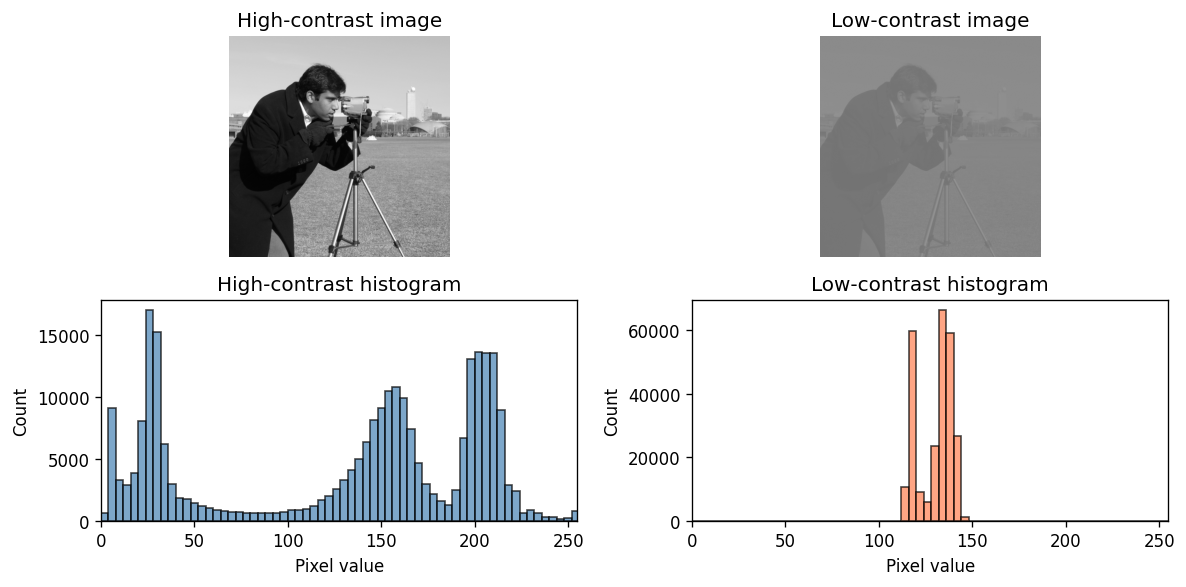

In [5]:
from skimage import data

# Load the test image
high_contrast = data.camera().astype(float)

# Create a low-contrast version by compressing the dynamic range
# Multiply by 0.12 to compress, then shift to mid-gray (115)
low_contrast = 115 + 0.12 * high_contrast

hist_bins = np.arange(0, 256 + 4, 4)

fig, axes = plt.subplots(2, 2, figsize=(10, 5))

# Top left: high contrast (original)
axes[0, 0].imshow(high_contrast, vmin=0, vmax=255)
axes[0, 0].set_title('High-contrast image')
axes[0, 0].axis('off')

# Top right: low contrast
axes[0, 1].imshow(low_contrast, vmin=0, vmax=255)
axes[0, 1].set_title('Low-contrast image')
axes[0, 1].axis('off')

# Bottom left: histogram of high contrast
# ravel() flattens the 2D image into a 1D array of pixel values for histogramming
axes[1, 0].hist(high_contrast.ravel(), bins=hist_bins, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('High-contrast histogram')
axes[1, 0].set_xlabel('Pixel value')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlim(0, 255)

# Bottom right: histogram of low contrast
axes[1, 1].hist(low_contrast.ravel(), bins=hist_bins, color='coral', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Low-contrast histogram')
axes[1, 1].set_xlabel('Pixel value')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()


## Noisy Images

Several major noise sources we might care about:

- **Shot noise**: stochastic fluctuations from a finite number of photons $\sim \sqrt{N_{\rm photon}}$.
- **Dark current**: detector signal even without incoming photons $\sim {\rm Temp}$.
- **Read noise**: electronic noise from amplification and digitization.
- **Background**: from other sources

![Noise comparison](media/noise_comparison.png)


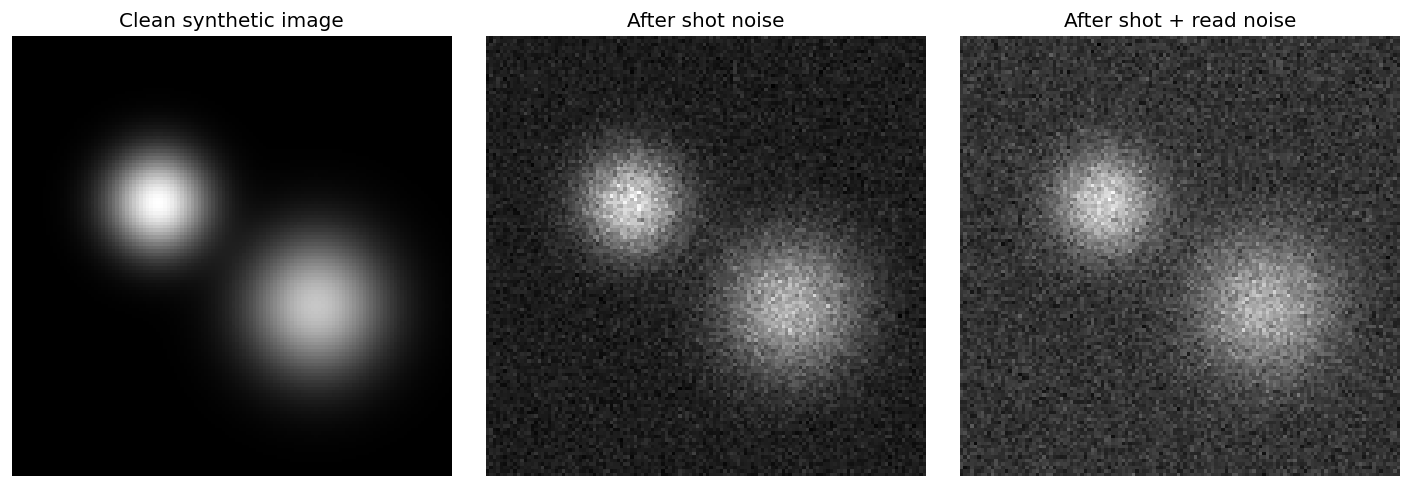

In [4]:
# Build a simple synthetic image and add shot-like and read noise.
yy, xx = np.mgrid[:128, :128]

# Two Gaussian blobs on top of a constant background.
clean_image = (
    20
    + 90 * np.exp(-((xx - 42) ** 2 + (yy - 48) ** 2) / (2 * 10**2))
    + 70 * np.exp(-((xx - 88) ** 2 + (yy - 78) ** 2) / (2 * 14**2))
)

# Shot noise is signal-dependent, so we model it with a Poisson distribution.
shot_noisy = np.random.poisson(clean_image).astype(float)

# Read noise is approximately additive Gaussian electronics noise.
noisy_image = shot_noisy + np.random.normal(0, 6, clean_image.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, data, title in zip(
    axes,
    [clean_image, shot_noisy, noisy_image],
    ['Clean synthetic image', 'After shot noise', 'After shot + read noise'],
):
    ax.imshow(data)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


## Dealing with Noise

- If you are fitting a function to the data, e.g. a Gaussian function to localize molecules, you can leave the noise alone (although you might add terms to the fit to deal with the noise)
- Photon and readout noise can be reduce with **Filtering**
- Background and autofluorescence can be removed with **Background Subtraction**


## Mean Filtering

- Each pixel is replaced with the **average** of the surrounding pixel values in a defined neighborhood.
- Works well for random pixel-scale noise
- Blurs edges

$$
I'(x,y) = \frac{1}{9} \sum_{i=-1}^1\sum_{j=-1}^1 I(x+i,y+j)
$$

![Mean filter Concept](media/MeanFilterBlocks.png)


![Mean filter Effects](media/MeanFilterEffects.png)

### Exercise 1

`media/PU_noisy.png` is a noisy image of the letters **PU**.

1. Write a function `mean_filter(image, N)` that applies an **N×N mean filter** to a 2-D grayscale image (as a NumPy array of floats). The function should work for any odd integer N ≥ 1. Handle the image borders by using only the pixels that exist (i.e., shrink the averaging window near the edges rather than padding).
2. Apply your filter with **N = 3, 5, and 7** to `media/PU_noisy.png`.
3. Display the original noisy image and the three filtered results in a 1×4 figure. Give each subplot an informative title and turn off axes.


In [21]:
noisy[10-(5//2):10+(5//2), 10-(5//2):10+(5//2)]

array([[0.18431373, 0.        , 0.        , 0.        ],
       [0.13725491, 0.        , 0.10588235, 0.        ],
       [0.        , 0.20392157, 0.05098039, 0.02745098],
       [0.        , 0.        , 0.25882354, 0.        ]], dtype=float32)

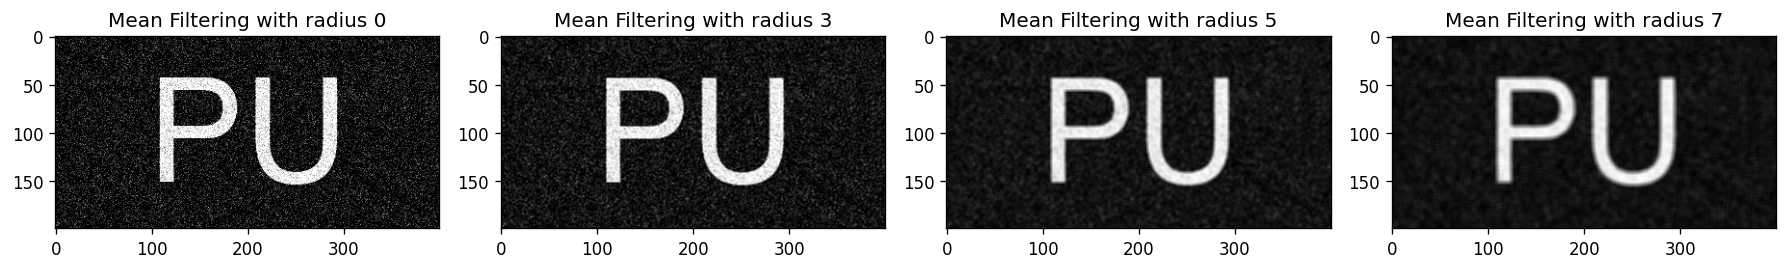

In [24]:
# Your code here
def mean_filter(image, N):
    xx, yy = image.shape
    new_image = np.zeros_like(image, dtype=float)
    pad = N//2

    if N==0:
        return(image)
    
    for x in range(xx):
        for y in range(yy):
            working = image[max(0,x-pad):min(xx, x+pad),max(0,y-pad):min(yy,y+pad)]
            new_image[x,y] = np.mean(working)
    return new_image

noisy = plt.imread('media/PU_noisy.png')

fig, axes = plt.subplots(1,4, figsize = (15,4))
Ns = [0, 3, 5, 7]
for cur_ax, radius in zip(axes, Ns):
    filtered = mean_filter(noisy, radius)
    cur_ax.imshow(filtered)
    cur_ax.set_title(f'Mean Filtering with radius {radius}')
    
plt.tight_layout()
plt.show()


## Median Filtering

A median filter replaces the center pixel with the **median** value in a neighborhood.

- Each pixel is replaced with the median of the surrounding pixel values in a defined neighborhood.
- Works well for isolated extreme noise pixels (hot pixels, salt-and-pepper noise) 
- Preserves edges **(WHY?)**
- Slower as the median is slower to calculate (sorting)


![Median filter blocks](media/medianfilterblocks.png)

![Median filter effects](media/medianfiltereffects.png)

Here is an example of a brute force calcuation:
```python
for i in range(1, H-1):
    for j in range(1, W-1):
        window = image[i-1:i+2, j-1:j+2].flatten()
        median_value = np.median(window)
        output[i-1, j-1] = median_value



## Gaussian Filtering

A Gaussian filter smooths an image by averaging each pixel with its neighbors using weights that are highest at the center and decrease with distance.

- It preserves edges better than a plain mean filter.
- It still blurs fine structure if `sigma` is too large.

This would be a 3x3 Gaussian Filter:

$$
I'(x,y) = \sum_{i=-1}^{1} \sum_{j=-1}^{1} G(i,j) I(x+i, y+j)
$$

with Gaussian weights

$$
G(i,j) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{i^2 + j^2}{2\sigma^2}\right).
$$


In [ ]:
# 3x3 Gaussian filter:
def gaussian(di, dj, sigma):
    return (1 / (2 * math.pi * sigma**2)) * math.exp(-(di**2 + dj**2) / (2 * sigma**2))


def gaussian_filter(image, sigma=1.0):
    image = image.astype(float)
    H, W = image.shape
    filtered = np.zeros((H - 2, W - 2), dtype=float)
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            weighted_sum = 0.0
            total_weight = 0.0
            for di in range(-1, 2):
                for dj in range(-1, 2):
                    weight = gaussian(di, dj, sigma)
                    weighted_sum += weight * image[i + di, j + dj]
                    total_weight += weight
            filtered[i - 1, j - 1] = weighted_sum / total_weight
    return filtered

Let's apply this to a noisy image with an edge between dark and light

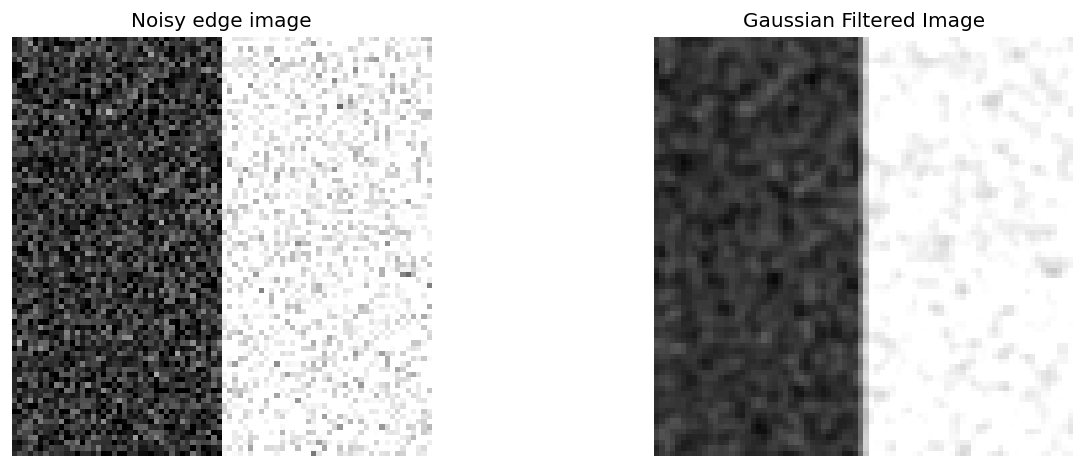

In [7]:
# Build a simple test image with a sharp vertical edge.
edge_image = np.zeros((80, 80), dtype=float)
edge_image[:, :40] = 0.2
edge_image[:, 40:] = 1.0

# Add Gaussian noise so we can see how smoothing affects both noise and edges.
rng = np.random.default_rng(4)
noisy_edge = edge_image + 0.15 * rng.normal(size=edge_image.shape)

brute_gaussian = gaussian_filter(noisy_edge, sigma=1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(noisy_edge, vmin=0, vmax=1)
axes[0].set_title('Noisy edge image')
axes[0].axis('off')
axes[1].imshow(brute_gaussian, vmin=0, vmax=1)
axes[1].set_title('Gaussian Filtered Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Convolutions in Image Processing

- A mathematical operation used to apply a filter (called a kernel) to an image. 

- Works by sliding a small matrix kernel over the image and computing a weighted sum of pixel values at each location.

    - Place the kernel over a pixel and its neighbors.

    - Multiply each neighboring pixel by the corresponding kernel value.
    - Sum the results.
    - Move the kernel across the image, repeating steps 1-3.

- We will use convolutions for many things, including smoothing, sharpening, edge detection, and feature extraction in images

### 3x3 Mean Filter as a convolution

The **kernel** is defined as:
$$
M = \frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

The filtered image is then given by the convolution of the original image with the kernel:

$$
I'(x,y) = \sum_{i=-1}^{1} \sum_{j=-1}^{1} M(i,j) I(x+i, y+j).
$$

Example Python code:

```python
# Define a 3x3 mean-filter kernel
kernel = np.ones((3, 3), dtype=float) / 9

# Convolve image with the kernel to get a mean-filtered image
# (mode='nearest' handles borders by repeating edge values)
mean_filtered = ndimage.convolve(noisy_image, kernel, mode='nearest')
```


### 3x3 Gaussian Filter as a convolution

To perform a Gaussian filter, we just need to redefine the kernel:
$$
G = \frac{1}{16}
\begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}
$$

Here we use $\sigma=1$.

In Python, you could calculate from the actual Gaussian function or just put in by hand:

```python
# Define a 3x3 Gaussian kernel
gaussian_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16
```


## Background Subtraction

- Microscopy images often contain unwanted background signal—intensity that isn’t part of the actual structures of interest but is not random, high frequency noise that can be filtered out. Sources are:

    1. Autofluorescence or scattered light from the sample

    2. Uneven illumination or shading from the objective (vignetting)
    
    3. Non-specific labeling/staining or fluorescence from the media/gel

- The solution is to subtract this unwanted signal from the image

- If using integers for your images (common), you need to be careful not to generate negative numbers when you subtract, called clipping. 

### Types of background

- Constant background: subtract a scalar

![Constant background](media/ConstantBackground.png)

- Nonuniform background: subtract a background image

![Nonuniform background](media/NonuniformBackground.png)

## Measuring the background image

### Static Background 

- Sometimes the background comes from non-uniform illumination, dust on the camera/optics

- In this case, you can sometimes take an image with a blank sample and use that as the background image.

![Static Background](media/StaticBackground.png)

### Rolling Ball / Gaussian Blur to estimate Background

- Estimate the background as a smoothed version of the original image using a large-sized filter, essentially the low spatial frequency information

- Use when illumination is uneven or gradual background variation

```python
import cv2
background = cv2.GaussianBlur(image, (101, 101), sigmaX=30)
image_subtracted = image - background
```

- `cv2` is the Python interface to OpenCV, a widely used computer vision and image-processing library. There are MANY useful functions in it!

### Median filter of temporal image series to estimate Background

- Assuming your sample has moving objects that don’t dwell too long in any particular location

- Compute the median at each pixel across time for a movie (image time series)

- Use in live-cell imaging or time-lapse movies, assuming moving objects average out and only the background remains

```python
median_background = np.median(stack, axis=0)
corrected = stack - median_background
```

<table>
<tr>
<td align="center" width="33%">
<video src="media/single_molecule_movie_longer_mobile.mp4" controls autoplay loop muted playsinline width="100%"></video><br>
Original movie
</td>
<td align="center" width="33%">
<img src="media/single_molecule_movie_median.png" alt="Temporal median background" width="100%"><br>
Median background
</td>
<td align="center" width="33%">
<video src="media/single_molecule_movie_longer_mobile_bgsub.mp4" controls autoplay loop muted playsinline width="100%"></video><br>
Background-subtracted movie
</td>
</tr>
</table>